In [1]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import sklearn
from sklearn.model_selection import train_test_split
from sklearn import neighbors
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn import metrics
from sklearn.model_selection import cross_val_predict, cross_val_score, cross_validate
from sklearn.model_selection import KFold, StratifiedKFold 

# Inspección inicial del dataset 

In [3]:
datos = pd.read_csv('hwc.csv', index_col=0)

In [5]:
datos.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5599 entries, OGLE-2016-BLG-1227L b to OGLE-2019-BLG-1180L b
Columns: 117 entries, P_DETECTION to S_CONSTELLATION_ENG
dtypes: float64(81), int64(18), object(18)
memory usage: 5.0+ MB


**N° de filas: 5599**

**N° de columnas: 117**

In [7]:
#nombre de cada columnna y tipo de dato de cada una
x=0
while x < 117:
    y=datos.columns[x]
    print(y,"\033[31m",datos[y].dtype,"\033[0m")
    x+=1

P_DETECTION  object 
P_DISCOVERY_FACILITY  object 
P_YEAR  int64 
P_UPDATE  object 
P_MASS  float64 
P_MASS_ERROR_MIN  float64 
P_MASS_ERROR_MAX  float64 
P_MASS_LIMIT  int64 
P_MASS_ORIGIN  object 
P_RADIUS  float64 
P_RADIUS_ERROR_MIN  float64 
P_RADIUS_ERROR_MAX  float64 
P_RADIUS_LIMIT  int64 
P_PERIOD  float64 
P_PERIOD_ERROR_MIN  float64 
P_PERIOD_ERROR_MAX  float64 
P_PERIOD_LIMIT  int64 
P_SEMI_MAJOR_AXIS  float64 
P_SEMI_MAJOR_AXIS_ERROR_MIN  float64 
P_SEMI_MAJOR_AXIS_ERROR_MAX  float64 
P_SEMI_MAJOR_AXIS_LIMIT  int64 
P_ECCENTRICITY  float64 
P_ECCENTRICITY_ERROR_MIN  float64 
P_ECCENTRICITY_ERROR_MAX  float64 
P_ECCENTRICITY_LIMIT  int64 
P_INCLINATION  float64 
P_INCLINATION_ERROR_MIN  float64 
P_INCLINATION_ERROR_MAX  float64 
P_INCLINATION_LIMIT  int64 
P_OMEGA  float64 
P_OMEGA_ERROR_MIN  float64 
P_OMEGA_ERROR_MAX  float64 
P_OMEGA_LIMIT  int64 
S_NAME  object 
S_NAME_HD  object 
S_NAME_HIP  object 
S_TYPE  object 
S_RA  float64 
S_DEC  float64 
S_RA_STR  object 
S_DEC

**variable objetivo: P_HABITABLE**

In [9]:
datos["P_HABITABLE"]

P_NAME
OGLE-2016-BLG-1227L b    0
Kepler-276 c             0
Kepler-829 b             0
K2-283 b                 0
Kepler-477 b             0
                        ..
HD 222155 b              0
HD 88986 b               0
Kepler-30 b              0
HD 3167 d                0
OGLE-2019-BLG-1180L b    0
Name: P_HABITABLE, Length: 5599, dtype: int64

In [11]:
#N° de datos faltantes en cada columna
cols=datos.columns
print("Datos faltantes")
for col in cols:
    datos[col].isnull().sum()
    print(col ,"\033[31m",datos[col].isnull().sum(),"\033[0m"," datos faltantes")

Datos faltantes
P_DETECTION  0   datos faltantes
P_DISCOVERY_FACILITY  0   datos faltantes
P_YEAR  0   datos faltantes
P_UPDATE  0   datos faltantes
P_MASS  7   datos faltantes
P_MASS_ERROR_MIN  3093   datos faltantes
P_MASS_ERROR_MAX  3093   datos faltantes
P_MASS_LIMIT  0   datos faltantes
P_MASS_ORIGIN  0   datos faltantes
P_RADIUS  7   datos faltantes
P_RADIUS_ERROR_MIN  1752   datos faltantes
P_RADIUS_ERROR_MAX  1752   datos faltantes
P_RADIUS_LIMIT  0   datos faltantes
P_PERIOD  249   datos faltantes
P_PERIOD_ERROR_MIN  728   datos faltantes
P_PERIOD_ERROR_MAX  728   datos faltantes
P_PERIOD_LIMIT  0   datos faltantes
P_SEMI_MAJOR_AXIS  4   datos faltantes
P_SEMI_MAJOR_AXIS_ERROR_MIN  2902   datos faltantes
P_SEMI_MAJOR_AXIS_ERROR_MAX  2902   datos faltantes
P_SEMI_MAJOR_AXIS_LIMIT  0   datos faltantes
P_ECCENTRICITY  777   datos faltantes
P_ECCENTRICITY_ERROR_MIN  3984   datos faltantes
P_ECCENTRICITY_ERROR_MAX  3984   datos faltantes
P_ECCENTRICITY_LIMIT  0   datos faltantes
P_

# Análisis de la variable objetivo 

In [15]:
#clases de la variable objetivo
clases=[]
for dato in datos["P_HABITABLE"]:
    if dato not in clases:
        clases.append(dato)
clases.sort()
clases


[0, 1, 2]

In [21]:
#cuantos ejemplos tiene cada clase

datos["P_HABITABLE"].value_counts()

P_HABITABLE
0    5529
2      41
1      29
Name: count, dtype: int64

<Figure size 800x400 with 0 Axes>

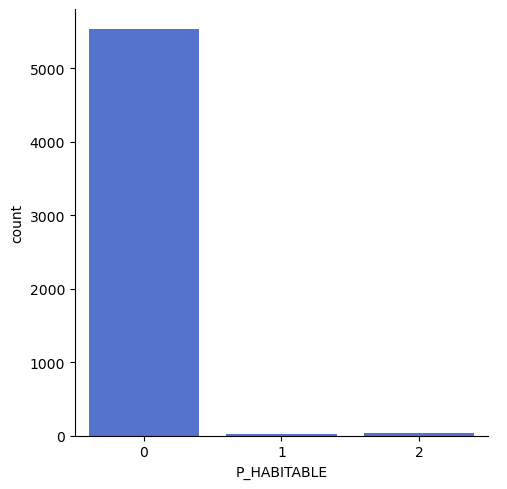

In [64]:
plt.figure(figsize=(8,4))
sns.catplot(data=datos, x='P_HABITABLE',kind='count', color='royalblue')
plt.show()

el problema esta desbalanceado ya que hay una mucho mayor cantidad de planetas no habitables que habitables

# Análisis exploratorio de variables predictoras 

Caracteristicas Relevantes:
1. P_HABZONE_OPT (0 datos faltantes)
2. P_HABZONE_CON (0 datos faltantes)
3. S_MASS (4 datos faltantes)
4. P_MASS (7 datos faltantes)
5. P_RADIUS (7 datos faltantes)

**Se eligieron este conjunto de variables ya que P_HABZONE_CON y P_HABZONE_opt condensan la informacion respecto a la estrella y la orbita del planeta necesaria para saber si es habitable, aun asi se usara S_MASS para tener un minimo de informacion sobre la estrella, en cuanto a P_MASS y P_RADIUS estas entregan informacion sobre el planeta que sirve para determinar su habitabilidad cuando se cumple el requisito de estar en la zona habitable**

In [31]:
#planeta en la zona habitable(optimista)
datos["P_HABZONE_OPT"].value_counts()

P_HABZONE_OPT
0    5335
1     264
Name: count, dtype: int64

<Figure size 800x400 with 0 Axes>

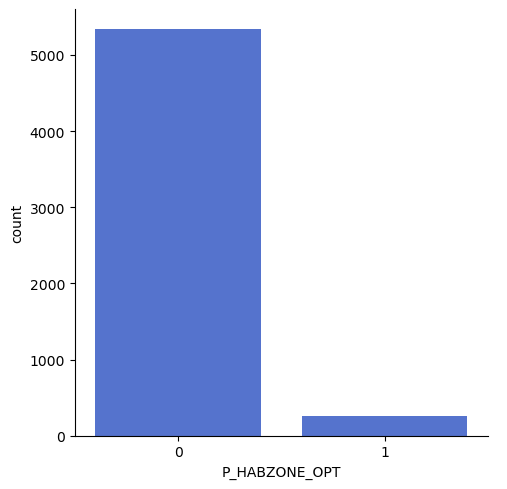

In [62]:
plt.figure(figsize=(8,4))
sns.catplot(data=datos, x='P_HABZONE_OPT',kind='count', color='royalblue')
plt.show()

Hay muchos más planetas que no estan en la zona habitable optimista que los que si

In [33]:
#planeta en zona habitable(consevador)
datos["P_HABZONE_CON"].value_counts()

P_HABZONE_CON
0    5411
1     188
Name: count, dtype: int64

<Figure size 800x400 with 0 Axes>

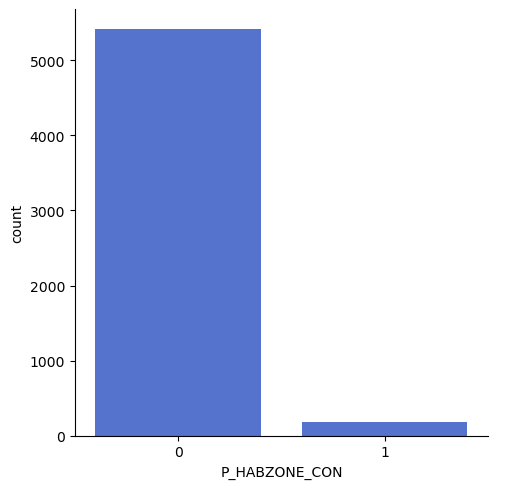

In [66]:
plt.figure(figsize=(8,4))
sns.catplot(data=datos, x='P_HABZONE_CON',kind='count', color='royalblue')
plt.show()

Hay muchos más planetas que no estan en la zona habitable conservadora que los que si

Text(0.5, 1.0, 'distribucion de masas')

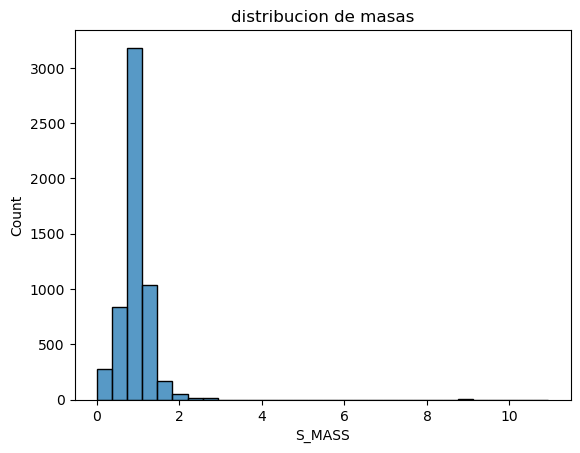

In [168]:
#histograma masas de las estrellas
sns.histplot(datos["S_MASS"],bins=30)
plt.title("distribucion de masas")

Text(0.5, 1.0, 'distribucion de masas')

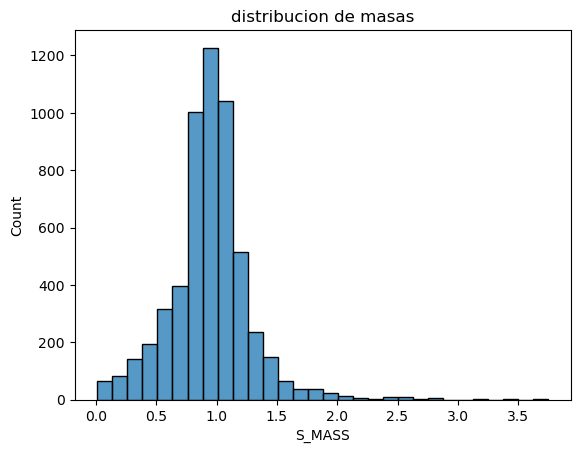

In [16]:
#histograma masas de las estrellas menores a 4 masas solares
masas=datos[datos["S_MASS"]<4]
sns.histplot(masas["S_MASS"],bins=30)
plt.title("distribucion de masas")

La mayoria de estrellas ronda una masa solar

Text(0.5, 1.0, 'distribucion de masas')

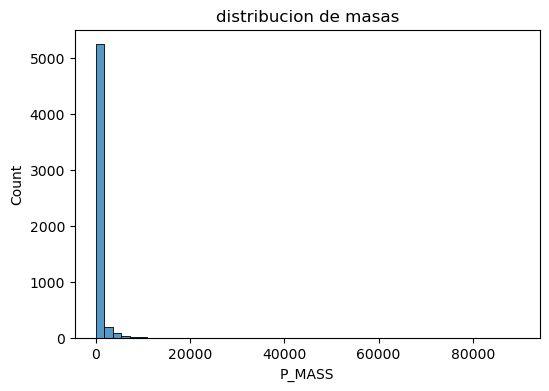

In [189]:
#histograma masas de los planetas
plt.figure(figsize=(6,4))
sns.histplot(datos["P_MASS"],bins=50)
plt.title("distribucion de masas")

Text(0.5, 1.0, 'distribucion de masas')

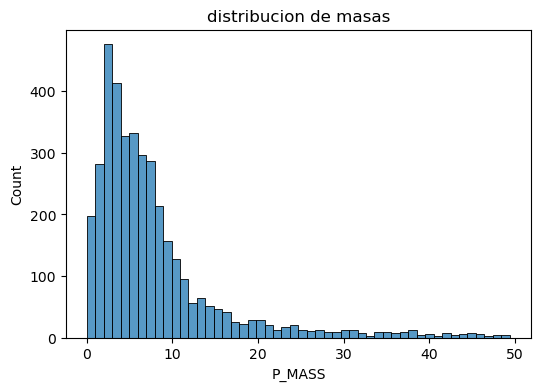

In [199]:
#histograma masas de los planetas hasta 50 masas terrestres
masas2=datos[datos["P_MASS"]<50]
plt.figure(figsize=(6,4))
sns.histplot(masas2["P_MASS"],bins=50)
plt.title("distribucion de masas")


La gran mayoria de los planetas tienen masas menores a 10 masas terrestres siendo la mayor cantidad cerca de las 3 masas terrestres

Text(0.5, 1.0, 'distribucion de radios')

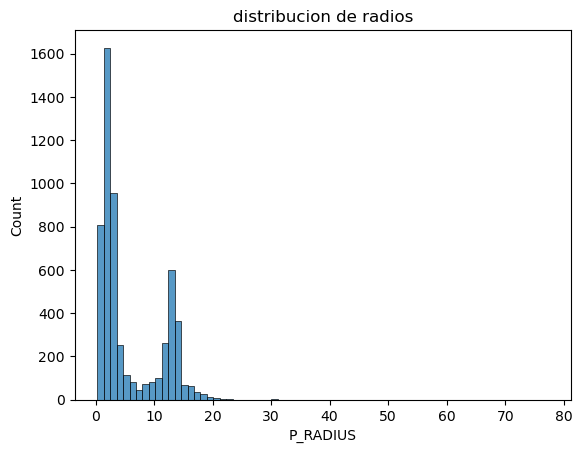

In [209]:
#histograma radios de los planetas
sns.histplot(datos["P_RADIUS"],bins=70)
plt.title("distribucion de radios")


Text(0.5, 1.0, 'distribucion de radios')

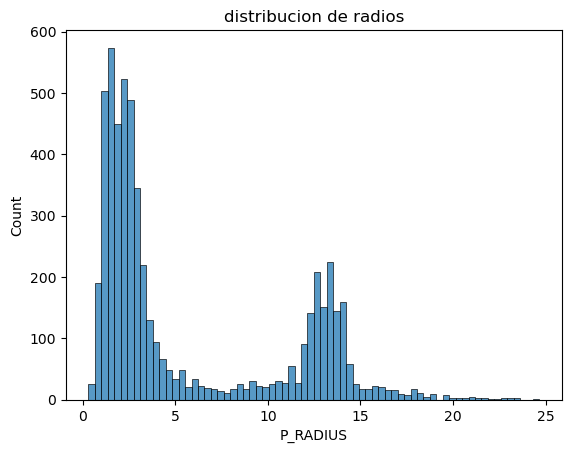

In [207]:
#histograma radios de los planetas menores a 25 radios terrestres
radios=datos[datos["P_RADIUS"]<25]
sns.histplot(radios["P_RADIUS"],bins=70)
plt.title("distribucion de radios")


La mayoria de los planetas poseen radios entre 10 y 15 radios terrestres y entre 0 y 5 radios terrestres estando la mayoria en este ultimo intervalo

# Selección de variables para modelar 

In [24]:
datos_finales=datos.dropna(subset=["P_MASS","P_RADIUS","S_MASS"]) #descartando filas con valores faltantes

In [17]:
datos_finales.info()

<class 'pandas.core.frame.DataFrame'>
Index: 5590 entries, OGLE-2016-BLG-1227L b to OGLE-2019-BLG-1180L b
Columns: 117 entries, P_DETECTION to S_CONSTELLATION_ENG
dtypes: float64(81), int64(18), object(18)
memory usage: 5.0+ MB


In [19]:
y=datos_finales["P_HABITABLE"] #variable objetivo
y=y.replace(2,1)
x=datos_finales[["P_MASS","P_RADIUS","S_MASS","P_HABZONE_CON","P_HABZONE_OPT"]] #features

In [21]:
y.value_counts()

P_HABITABLE
0    5520
1      70
Name: count, dtype: int64

# Preparación de los datos 

Se descartaron las filas con valores faltantes ya que eran muy pocas(9 filas) ademas la variable P_HABITABLE paso de tener las clases 0, 1 y 2 a 0 y 1 juntando las antiguas clases 1 y 2 para conformar la nueva clase 1

In [85]:
Xtrain, Xtest, Ytrain, Ytest = train_test_split(x,y,test_size=0.25,stratify=y,random_state=23) 

# Entrenamiento del modelo 

In [87]:
model15=neighbors.KNeighborsClassifier(n_neighbors = 15)

In [91]:
model13=neighbors.KNeighborsClassifier(n_neighbors = 13)

In [93]:
model7=neighbors.KNeighborsClassifier(n_neighbors = 7)

In [133]:
model5=neighbors.KNeighborsClassifier(n_neighbors = 5)

In [117]:
model15

KNeighborsClassifier(n_neighbors=15)

In [119]:
model13

KNeighborsClassifier(n_neighbors=13)

In [121]:
model7

KNeighborsClassifier(n_neighbors=7)

In [135]:
model5

KNeighborsClassifier()

# Escalado de variables 

In [137]:
scaler = sklearn.preprocessing.RobustScaler()

In [139]:
scaler.fit(Xtrain)

RobustScaler()

In [141]:
sXtrain=scaler.transform(Xtrain)

In [143]:
sXtest=scaler.transform(Xtest)

In [145]:
sXtrain=pd.DataFrame(sXtrain)

In [147]:
sXtest=pd.DataFrame(sXtest)

Se aplica escalamiento a las variables ya que poseen magnitudes distintas que pueden afectar las predicciones realizadas por el modelo

# Exploración acotada del valor de k 

In [210]:
cv = StratifiedKFold(shuffle = True, n_splits = 4, random_state=23) #para posterior validacion cruzada

### K=15

In [200]:
model15.fit(sXtrain,Ytrain)
ypredict15=model15.predict(sXtest)

In [202]:
cm15 = confusion_matrix(Ytest, ypredict15)
cm15

array([[1376,    4],
       [   3,   15]], dtype=int64)

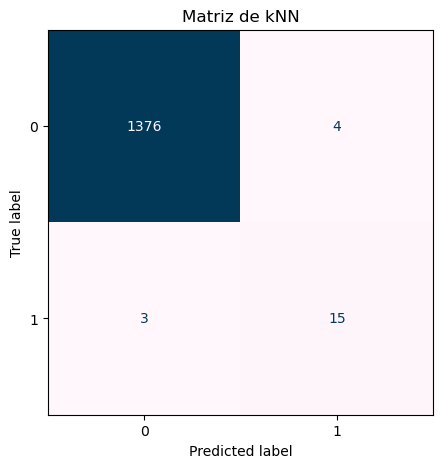

In [204]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm15, display_labels=["0", "1"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de kNN")
plt.show()

In [206]:
print("Precision:", metrics.precision_score(Ytest, ypredict15))
print("Recall   :", metrics.recall_score(Ytest, ypredict15))
print("F1-score :", metrics.f1_score(Ytest, ypredict15))

Precision: 0.7894736842105263
Recall   : 0.8333333333333334
F1-score : 0.8108108108108109


In [220]:
scores15 = cross_validate(model15, x, y, cv = cv, scoring = 'f1')
print("{:.3f}".format(scores15['test_score'].mean()), "{:.3f}".format(scores15['test_score'].std()))

0.724 0.067


### K=13

In [176]:
model13.fit(sXtrain,Ytrain)
ypredict13=model13.predict(sXtest)

In [178]:
cm13 = confusion_matrix(Ytest, ypredict13)
cm13

array([[1375,    5],
       [   3,   15]], dtype=int64)

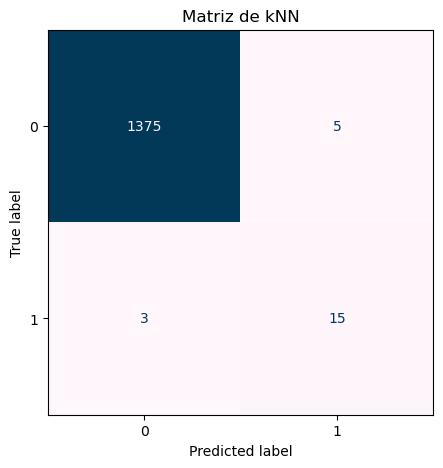

In [180]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm13, display_labels=["0", "1"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de kNN")
plt.show()

In [182]:
print("Precision:", metrics.precision_score(Ytest, ypredict13))
print("Recall   :", metrics.recall_score(Ytest, ypredict13))
print("F1-score :", metrics.f1_score(Ytest, ypredict13))

Precision: 0.75
Recall   : 0.8333333333333334
F1-score : 0.7894736842105263


In [222]:
scores13 = cross_validate(model13, x, y, cv = cv, scoring = 'f1')
print("{:.3f}".format(scores13['test_score'].mean()), "{:.3f}".format(scores13['test_score'].std()))

0.735 0.073


### K=7

In [184]:
model7.fit(sXtrain,Ytrain)
ypredict7=model7.predict(sXtest)

In [186]:
cm7 = confusion_matrix(Ytest, ypredict7)
cm7

array([[1375,    5],
       [   2,   16]], dtype=int64)

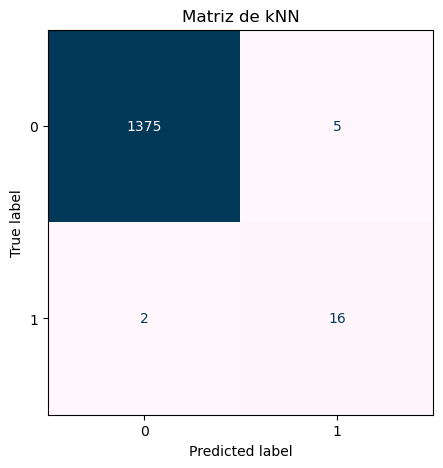

In [188]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm7, display_labels=["0", "1"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de kNN")
plt.show()

In [190]:
print("Precision:", metrics.precision_score(Ytest, ypredict7))
print("Recall   :", metrics.recall_score(Ytest, ypredict7))
print("F1-score :", metrics.f1_score(Ytest, ypredict7))

Precision: 0.7619047619047619
Recall   : 0.8888888888888888
F1-score : 0.8205128205128205


In [224]:
scores7 = cross_validate(model7, x, y, cv = cv, scoring = 'f1')
print("{:.3f}".format(scores7['test_score'].mean()), "{:.3f}".format(scores7['test_score'].std()))

0.847 0.087


### K=5

In [192]:
model5.fit(sXtrain,Ytrain)
ypredict5=model5.predict(sXtest)

In [194]:
cm5 = confusion_matrix(Ytest, ypredict5)
cm5

array([[1375,    5],
       [   2,   16]], dtype=int64)

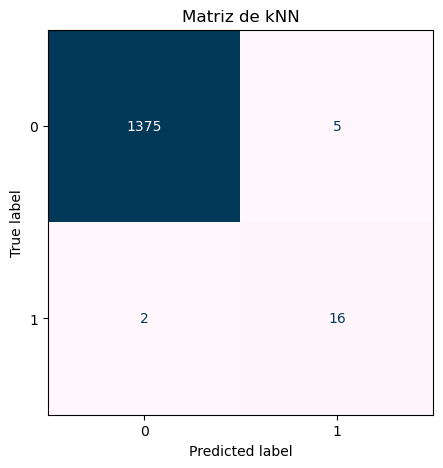

In [196]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=["0", "1"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de kNN")
plt.show()

In [198]:
print("Precision:", metrics.precision_score(Ytest, ypredict5))
print("Recall   :", metrics.recall_score(Ytest, ypredict5))
print("F1-score :", metrics.f1_score(Ytest, ypredict5))

Precision: 0.7619047619047619
Recall   : 0.8888888888888888
F1-score : 0.8205128205128205


In [226]:
scores5 = cross_validate(model5, x, y, cv = cv, scoring = 'f1')
print("{:.3f}".format(scores5['test_score'].mean()), "{:.3f}".format(scores5['test_score'].std()))

0.904 0.053


# Conclusión del modelo 

El valor más adeacuado de k entre 5, 7, 13 y 15 fue 5 luego de ver los resultados de las metricas fue el valor que mejores metricas consiguio y mostro ser el valor de k que entrega el modelo más robusto comprobado mediante validacion cruzada

Ventajas de knn: facil de implementar, solo se ajusto un hiperparametro el cual es k

Limitaciones de knn: sensible al ruido, necesidad de escalar los datos

# Métricas a reportar 

In [233]:
print("Precision:", metrics.precision_score(Ytest, ypredict5))
print("Recall   :", metrics.recall_score(Ytest, ypredict5))
print("Accuracy :", metrics.accuracy_score(Ytest, ypredict5))

Precision: 0.7619047619047619
Recall   : 0.8888888888888888
Accuracy : 0.9949928469241774


Precision: Mide que tan bien el modelo evita falsos positivos

Recall: Mide que tan bien el modelo capta verdaderos positivos

Accuracy: Mide que tantas prediciones correctas realizo el modelo

Para este caso Precision y Recall son las metricas más confiables ya que Accuracy se ve afectada por el desbalance de clases

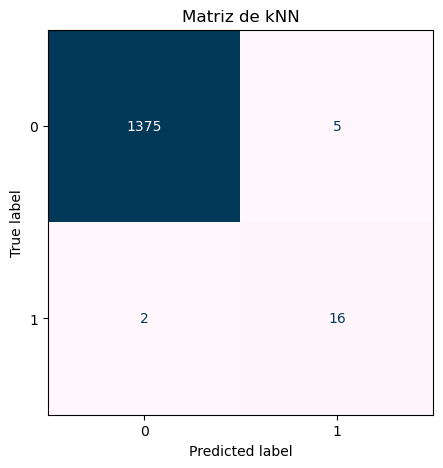

In [235]:
fig, ax = plt.subplots(figsize=(5,5))
disp = ConfusionMatrixDisplay(confusion_matrix=cm5, display_labels=["0", "1"])
disp.plot(cmap="PuBu", ax=ax, colorbar=False)

plt.title("Matriz de kNN")
plt.show()

# Reflexión sobre el desbalance de clases

1. El dataset presenta desbalance de clases
2. Accuracy suele no ser confiable cuando hay un desbalance de clases
3. La matriz de confusion muestra como fue clasificado cada dato en comparacion de cual era su clasificacion real
4. Recall mide que tantos planetas realmente habitables fueron clasificados como habitables y Precision mide que tantos planetas clasificados como habitables realmente lo eran
5. Para encontrar la mayor cantidad de planetas habitables se busca evitar los falsos negativos por lo que recall resulta especialmente importante

# Conclusiones finales

Finalmente respecto al dataset se pudo condensar la informacion sabiendo que es la zona habitable pudiendo entrenar el modelo con unas pocas features ademas gracias a esto se logro perder pocas filas del dataset ya que solo se perdieron 9 filas de un total de 5599, respecto al modelo este probo mejorar a medida que se disminuyo el valor de k probablemente debido al desbalance de clases aun asi viendo las metricas obtenidas el modelo no es malo aunque no es el mejor siendo mejor captando verdaderos positivos que evitando falsos positivos